In [26]:
import sys, os, re
import copy, glob, yaml, json, math
import importlib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d, gaussian_filter1d, percentile_filter
from scipy.stats import binned_statistic, zscore
import scipy.stats as stats
import suite2p 
from suite2p.extraction import dcnv
import pandas as pd
import glob 
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
import wesanderson
from cycler import cycler
import palettes
pio.renderers.default = "browser"

import neural_analysis_helpers
importlib.reload(neural_analysis_helpers)

from neural_analysis_helpers import get_psth, plot_avg_psth, split_psth, get_tuned_neurons, plot_avg_goal_psth, \
    get_landmark_psth, plot_avg_landmark_psth, plot_landmark_psth_map, plot_condition_psth_map, get_map_correlation, \
    get_tuned_neurons_shohei, get_rewards, get_rewarded_landmarks, get_landmark_category_entries, get_landmark_category_rew_idx, \
    get_landmark_categories, load_vr_behaviour_data, load_nidaq_behaviour_data, get_lm_entry_exit, load_vr_session_info, get_position_info, \
    get_landmark_id_psth, get_VR_rewards, plot_psth_single_neurons, get_rolling_map_correlation, get_window_similarity_matrix, \
    threshold_nidaq_licks, get_licks, get_data_lm_idx, get_binary_lick_map, get_lick_rate, get_lm_lick_rate, get_lick_types, \
    get_first_licks, get_event_lick_rate, get_smoothed_lick_rate

import parse_session_functions
importlib.reload(parse_session_functions)

from parse_session_functions import load_session, load_config, create_session_struct, get_lap_idx, get_lm_idx, calc_laps_needed, get_active_goal, get_rewarded_lms, get_lms_visited

tm_palette = palettes.met_brew('Tam',n=123, brew_type="continuous")
tm_palette = tm_palette[::-1]
color_scheme = wesanderson.film_palette('Darjeeling Limited',palette=0)
custom_cycler = cycler(color=color_scheme)
hfs_palette = np.array(palettes.met_brew('Austria',n=8, brew_type="continuous"))

#### Load data

In [11]:
# Define relevant directories and session specific info
basepath = '/Volumes/mrsic_flogel/public/projects/AtApSuKuSaRe_20250129_HFScohort2'
animal = 'TAA0000066'
sess = 'ses-011_date-20250315_protocol-t5'
sess_data_path = basepath + '/' + animal + '/' + sess
func_img_path = 'funcimg/Session'
save_path = sess_data_path + '/analysis'
if not os.path.exists(save_path):
    os.makedirs(save_path)

protocol_num = int(re.search(r'protocol-t(\d+)', sess).group(1))
print(f'Working on T{protocol_num}')
ABCD_goals = [1,2,3,4]

if animal == 'TAA0000066' or animal == 'TAA0000059':
    if protocol_num == 3 or protocol_num == 4:
        sequence = 'AB_shuffled'
    elif protocol_num == 5 or protocol_num == 6:
        sequence = 'ABAB'
    else:
        print('This code does not work before T3 or beyond T6 yet.')
elif animal == 'TAA0000061' or animal == 'TAA0000064':
    if protocol_num == 3 or protocol_num == 4:
        sequence = 'AABB'
    elif protocol_num == 5 or protocol_num == 6:
        sequence = 'AABB'
    else:
        print('This code does not work before T3 or beyond T6 yet.')
elif animal == 'TAA0000062' or animal == 'TAA0000065':
    if protocol_num == 3 or protocol_num == 4:
        sequence = 'AB_shuffled'
    elif protocol_num == 5 or protocol_num == 6:
        sequence = 'AABB'
    else:
        print('This code does not work before T3 or beyond T6 yet.')
else:
    raise ValueError("Oops I don't know what to do about this mouse")

# Recording params
nidaq_sampling_rate = 9000
vdaq_sampling_rate = 5000
funcimg_frame_rate = 45  # frames/s
if protocol_num <= 5:
    funcimg_recording_duration = 30 # min 
elif protocol_num >= 6:
    funcimg_recording_duration = 45 # min 
else:
    print('Please specify the funcimg recording duration!')
    
save_npz = True
save_csv = True

Working on T5


In [12]:
# Load data 

# Load nidaq data 
nidaq_data = load_nidaq_behaviour_data(sess_data_path)

# Load behaviour relevant frames 
valid_frames = np.load(os.path.join(sess_data_path, 'valid_frames.npz'))['valid_frames']

# Load VR data 
VR_data, options = load_vr_behaviour_data(sess_data_path)
session = create_session_struct(VR_data, options)
session = get_lap_idx(session)
session = get_lm_idx(session)
session = get_rewarded_lms(session)
session = get_active_goal(session)
session = calc_laps_needed(session)
session = get_lms_visited(options, session)

print('Number of laps = ', session['num_laps'])
num_lms = len(session['all_landmarks'])
print('Number of landmarks visited = ', num_lms)

rulename = options['sequence_task']['rulename']
if rulename == 'run-auto' or rulename == 'run-lick':  # stages 1-2
    start_odour = False  # VR started with reward delivery
elif rulename == 'olfactory_shaping' or rulename == 'olfactory_test':  # stages 3-6
    start_odour = True  # first VR event was the odour delivery prep

    if rulename == 'olfactory_test':
        num_landmarks = 10
    else:
        num_landmarks = 2
        # print('Please specify the number of landmarks in the corridor!')  # TODO: read this from config file

# Load suite2p outputs
ops = np.load(os.path.join(sess_data_path, func_img_path, 'suite2p/plane0/ops.npy'), allow_pickle=True).item()
iscell = np.load(os.path.join(sess_data_path, func_img_path, 'suite2p/plane0/iscell.npy'))[:,0]

neurons = np.where(iscell == 1)[0]  # select ROIs that are classified as neurons
num_neurons = len(neurons)


Speed threshold: 7
Number of laps =  1
Number of landmarks visited =  281


In [13]:
# Get landmark information 

# 1. Find data idx closest to landmark entry and exit
lm_entry_idx, lm_exit_idx = get_lm_entry_exit(session, positions=nidaq_data['position'])

# 2. Define which landmarks belong to goals, non-goals and test
session = get_landmark_categories(sequence, num_landmarks, session)

# 3. Find licks TODO might need to use get_licks function
# lick_idx = np.where(nidaq_data['licks'] == 1)[0]
session = get_licks(nidaq_data, session)

# 4. Find landmarks that were rewarded
session = get_rewarded_landmarks(VR_data, nidaq_data, session)

# 5. Find landmark entries by catetory 
rew_lm_entry_idx, miss_lm_entry_idx, nongoal_lm_entry_idx, test_lm_entry_idx = \
    get_landmark_category_entries(VR_data, nidaq_data, sequence, num_landmarks, session)

# 6. Find indices of rewards or 'imaginary' rewards in rewarded and non-rewarded landmarks
session = get_landmark_category_rew_idx(sequence, num_landmarks, session, VR_data, nidaq_data)

Total rewards considered here:  100
Total rewards not considered here:  9
Total assistant and manual rewards:  9
Reward time lag from lm entry:  27.0


#### Compute DF/F

In [41]:
# Load F and Fneu
calculate_DF_F = False

DF_F_file = os.path.join(sess_data_path, func_img_path, 'suite2p/plane0/DF_F0.npy')

if os.path.exists(DF_F_file) and calculate_DF_F is False:
    print('DF_F0 file found. Loading...')
    
    DF_F_all = np.load(DF_F_file)
    DF_F = DF_F_all[:, valid_frames]
    print(DF_F.shape)
    
else:
    calculate_DF_F = True
    F = np.load(os.path.join(sess_data_path, func_img_path, 'suite2p/plane0/F.npy'))
    Fneu = np.load(os.path.join(sess_data_path, func_img_path, 'suite2p/plane0/Fneu.npy'))

DF_F0 file found. Loading...
(624, 78437)


In [42]:
# Option 1 - Sandra: using moving percentile for F0 (https://www.nature.com/articles/s41586-021-03452-z#Sec7)
# F0 is defined as the 25th percentile of the fluorescence trace in a sliding window of 60 s
# The average green fluorescence signal was extracted for each cell and then corrected for neuropil contamination 
# by subtracting the signal of 30 μm surrounding each cell multiplied by 0.7 and adding the median multiplied by 0.7

if calculate_DF_F:
    Fcorr = F - 0.7 * Fneu + 0.7 * np.median(Fneu, axis=1).reshape(-1,1)

    F0 = np.zeros(np.shape(F))
    f0_window = 60 * funcimg_frame_rate  # frames
    for n in neurons:  # Loop over neurons (rows)
        F0[n, :] = percentile_filter(F[n, :], percentile=25, size=f0_window, mode='nearest')

    DF_F_all = (Fcorr - F0) / F0  # Compute DF/F as (F-F0)/F0 per frame per neuron

    # Select the correct frames that fall within VR behaviour 
    DF_F = DF_F_all[:, valid_frames]

    for n in neurons[0:10]:
        plt.figure()
        plt.plot(F[n,0:2000], label='F')
        plt.plot(Fcorr[n,0:2000], label='Fcorr')
        plt.plot(F0[n,0:2000], label='F0')
        plt.plot(DF_F[n,0:2000], label='DF/F0')
        plt.legend()

In [43]:
# Option 2 - suite2p: and dividing by mean F0 (https://github.com/MouseLand/suite2p/issues/598)
# For computing and subtracting baseline:
# baseline = 'maximin' # take the running max of the running min after smoothing with gaussian
# sig_baseline: in bins, standard deviation of gaussian with which to smooth
# win_baseline: in seconds, window in which to compute max/min filters
# if calculate_DF_F:
#     prctile_baseline = 25

#     F0 = 0.7 * Fneu
#     mean_F0 = np.mean(F0, axis=1)

#     DF = F.copy() - F0
#     DF = dcnv.preprocess(DF, ops['baseline'], ops['win_baseline'], ops['sig_baseline'], ops['fs'], prctile_baseline)

#     DF_F_all = DF / mean_F0.reshape(-1, 1)  # normalize by mean F0  (https://suite2p.readthedocs.io/en/latest/FAQ.html)

#     # Select the correct frames that fall within VR behaviour 
#     DF_F = DF_F_all[:, valid_frames]
#     print(DF_F.shape)

#     for n in neurons[0:10]:
#         plt.figure()
#         plt.plot(F[n,0:2000], label='F')
#         plt.plot(F0[n,0:2000], label='F0')
#         plt.plot(DF_F[n,0:2000], label='DF/F0')
#         plt.legend()

#     # Save data 
#     np.save(DF_F_file, DF_F_all)

In [44]:
# Option 3 - suite2p: but adding arbitrary value to F0 computed by suite2p to avoid division by zero.

# prctile_baseline = 25

# F0 = 0.7 * (Fneu + 15)  # add arbitrary value to F0 computed by suite2p 

# DF = F.copy() - F0
# DF = dcnv.preprocess(DF, ops['baseline'], ops['win_baseline'], ops['sig_baseline'], ops['fs'], prctile_baseline)

# DF_F_all = DF / F0

# # Select the correct frames that fall within VR behaviour 
# DF_F = DF_F_all[:, valid_frames]
# print(DF_F.shape)

# for n in neurons[0:10]:
#     plt.figure()
#     plt.plot(F[n,0:2000], label='F')
#     plt.plot(F0[n,0:2000], label='F0')
#     plt.plot(DF_F[n,0:2000], label='DF/F0')
#     plt.legend()

In [45]:
# Option 4 - Shohei: Gaussian mixture model on F (https://www.nature.com/articles/s41586-024-07851-w#Sec6)
# Calcium ΔF/F0 signals were obtained by using the baseline fluorescence F0, which is estimated by a 
# Gaussian mixture model with two components fitted on the raw fluorescence data. The mean parameter of 
# the lowest Gaussian component is used as F0. 
# from sklearn.mixture import GaussianMixture

# def estimate_f0_gmm(trace):
#     # Fit GMM with 2 components
#     gmm = GaussianMixture(n_components=2, random_state=0)
#     gmm.fit(trace.reshape(-1, 1))

#     # Get the means of the components
#     means = gmm.means_.flatten()
        
#     # Select the mean of the component with the lowest mean value
#     f0 = np.min(means)

#     return f0

# F0 = np.array([estimate_f0_gmm(trace) for trace in F])
# print(F0.shape)

# DF_F_all = (F - F0[:, np.newaxis]) / F0[:, np.newaxis]

# # Select the correct frames that fall within VR behaviour 
# DF_F = DF_F_all[:, valid_frames]
# print(DF_F.shape)

# for n in neurons[0:10]:
#     plt.figure()
#     plt.plot(F[n, :2000], label='F')
#     plt.axhline(F0[n], color='gray', linestyle='--', label='F0')
#     plt.plot(DF_F_all[n, :2000], label='ΔF/F₀')
#     plt.legend()


Out of the 624 ROIs, 517 are classified as neurons, and 319 have time-varying Ca2+ signals and will be considered here.


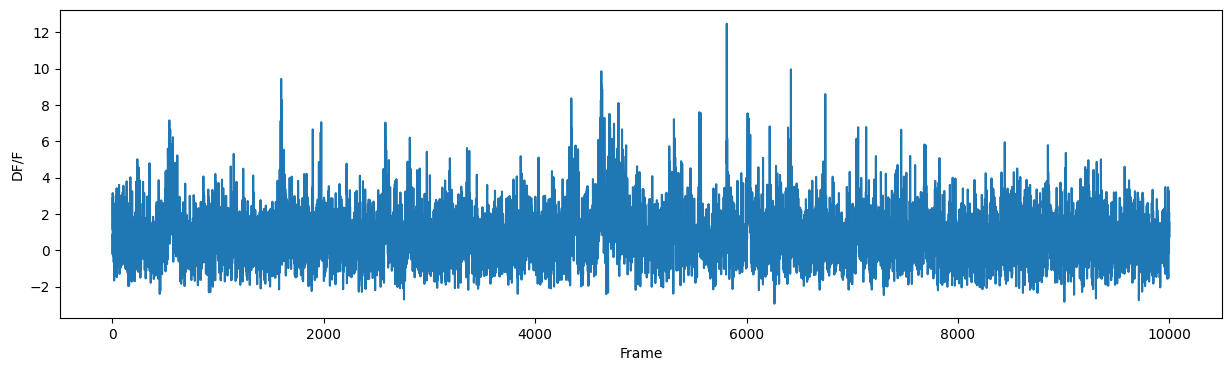

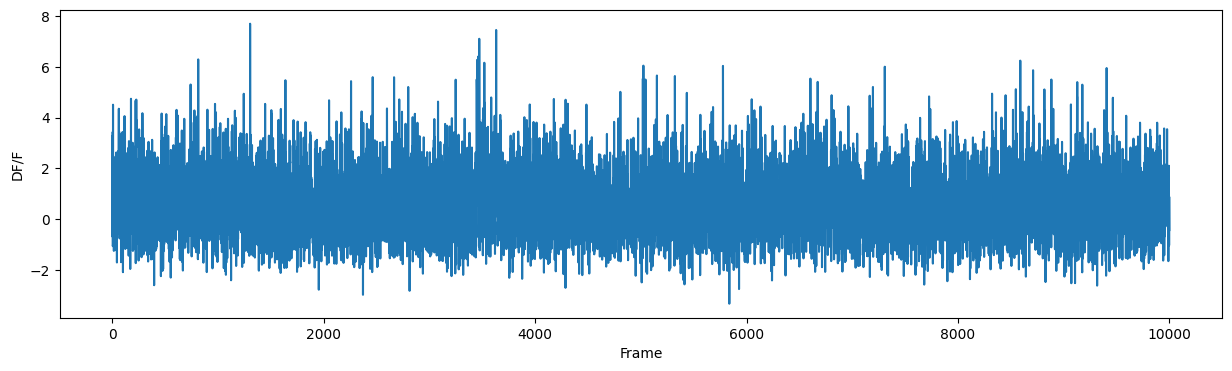

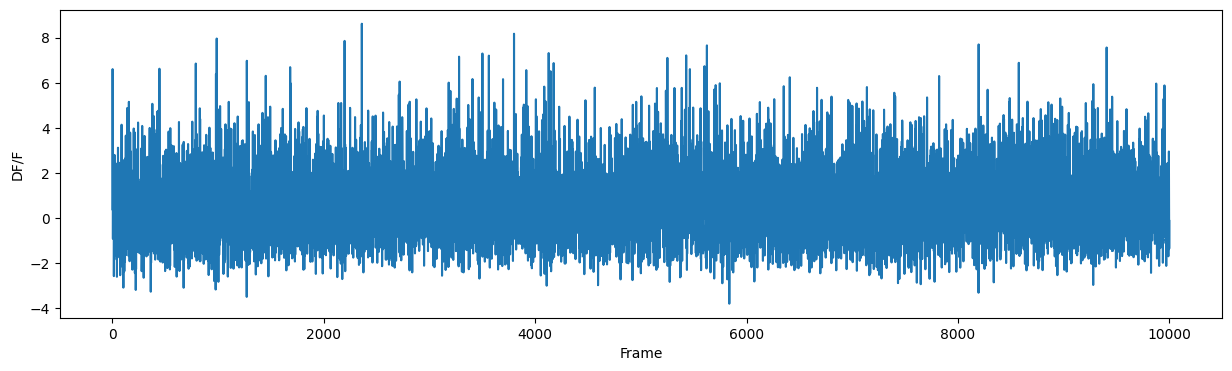

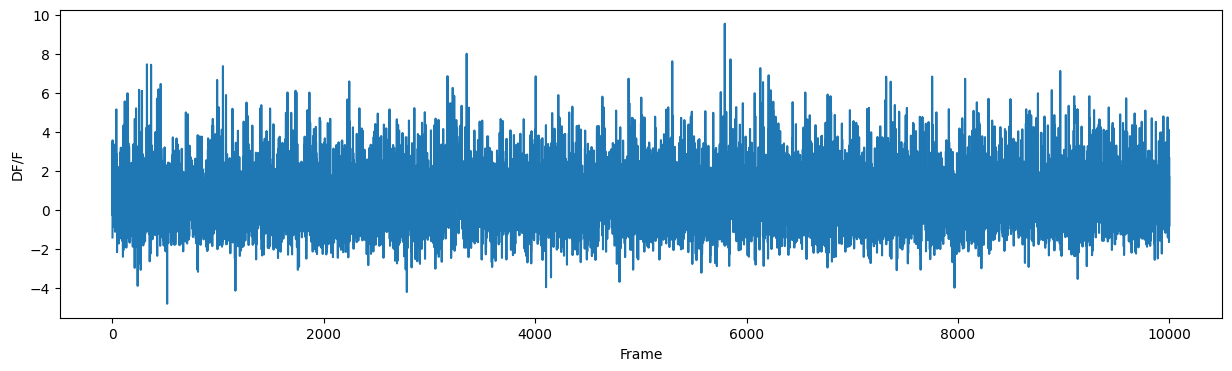

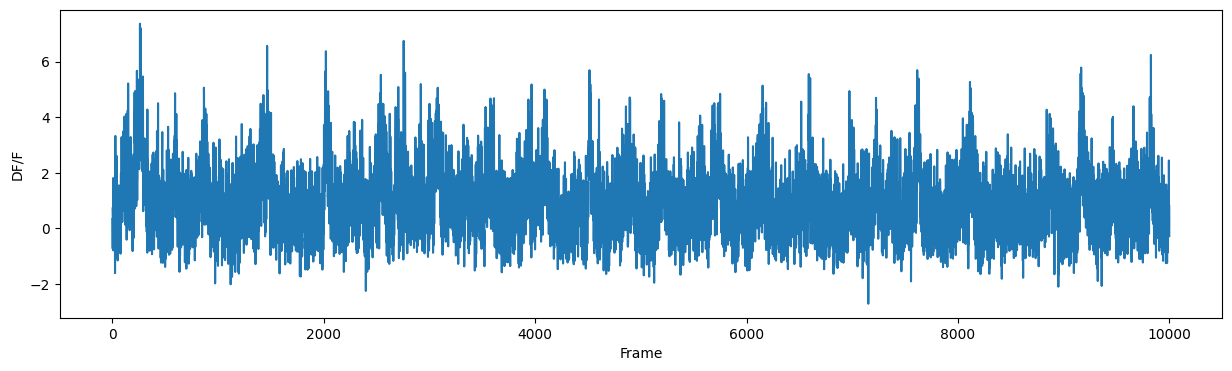

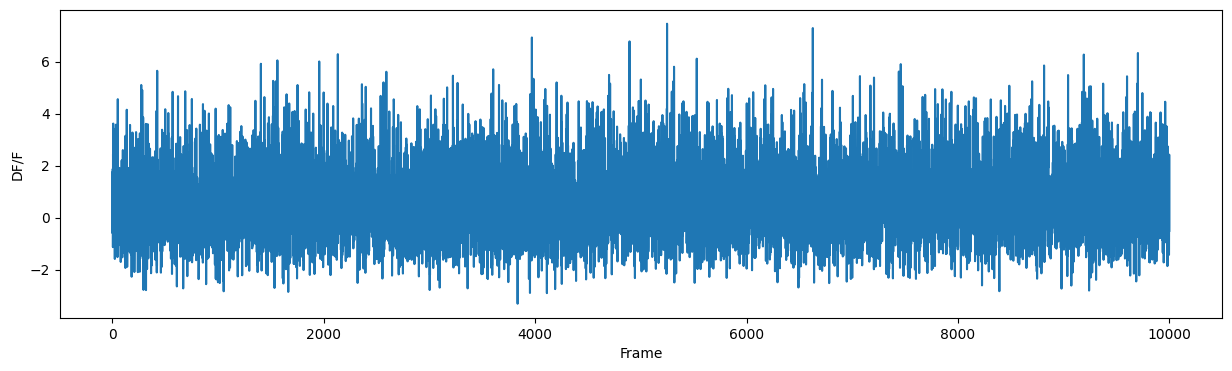

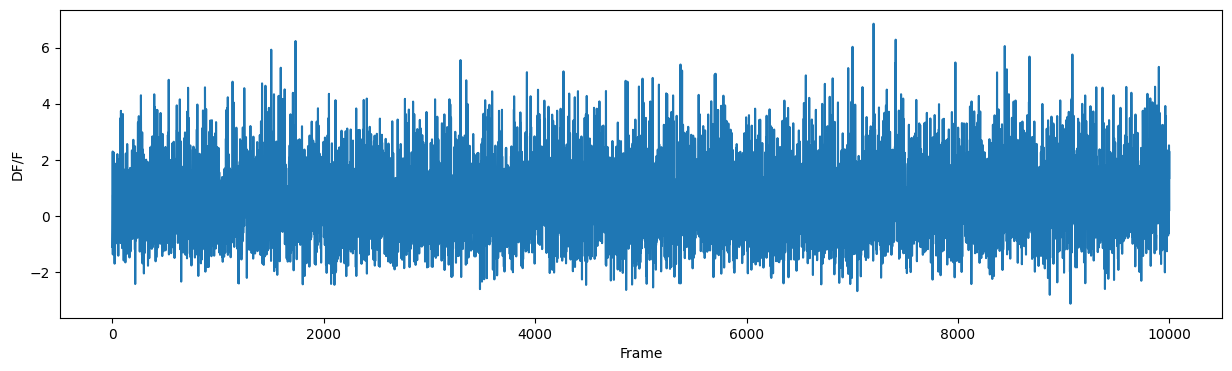

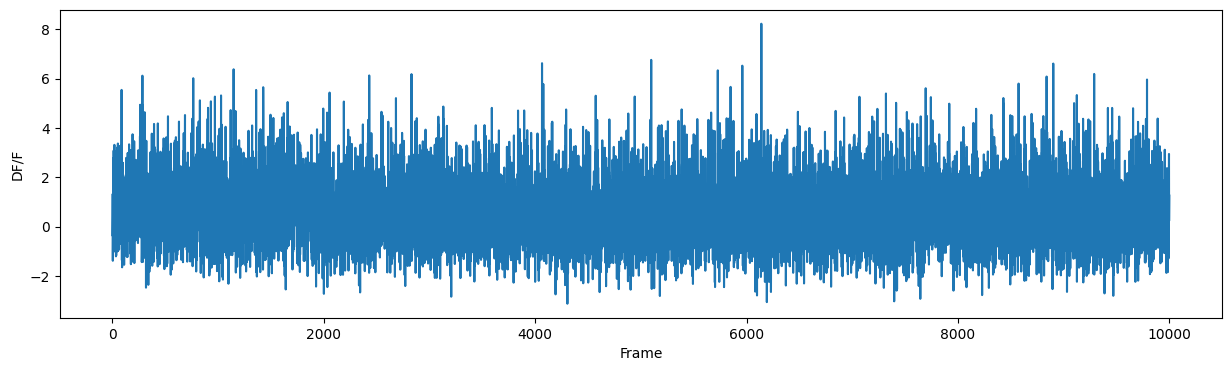

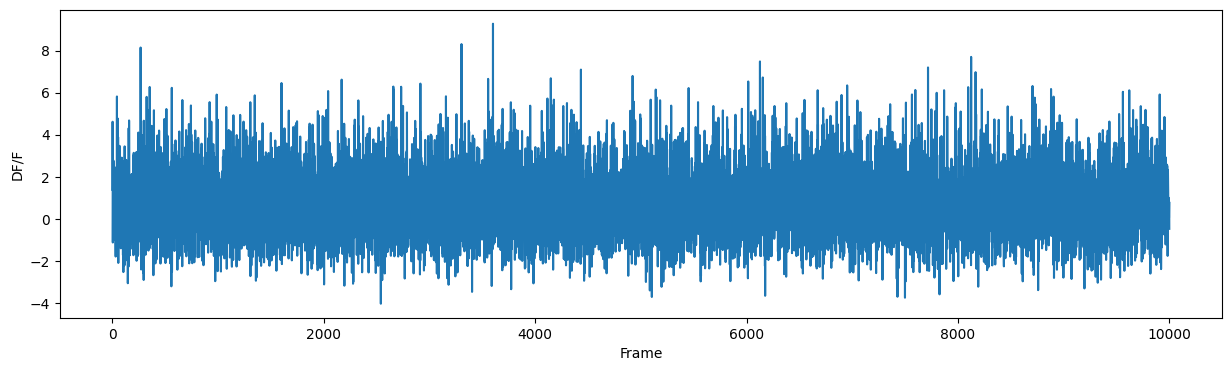

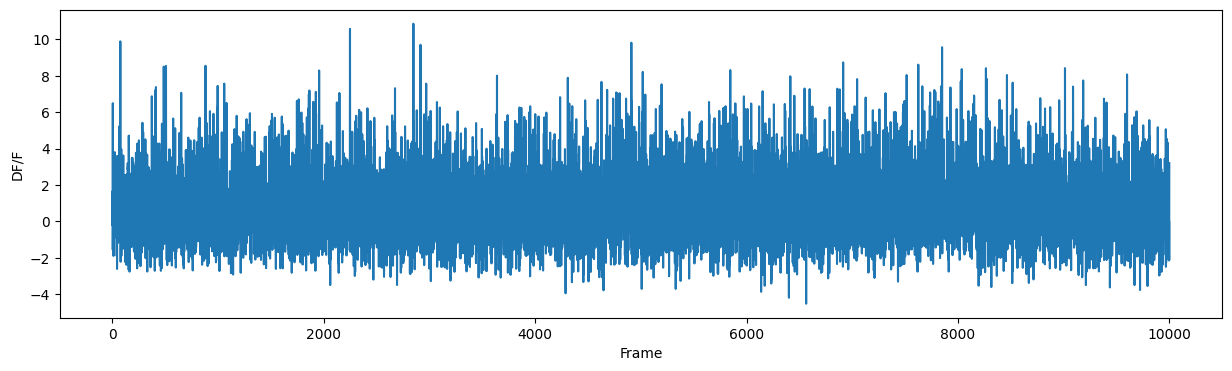

In [46]:
# Look at distribution of DF/F to select neurons
neurons_considered = []

for n in neurons: 
    deltas = DF_F[n,:] - np.mean(DF_F[n,:])
    # plt.hist(deltas, bins=100)
    skew = stats.skew(deltas)

    if np.abs(skew) > 0.5:  # TODO: confirm 
        neurons_considered.append(n)

num_neurons_considered = len(neurons_considered)
print(f'Out of the {DF_F.shape[0]} ROIs, {num_neurons} are classified as neurons, and {num_neurons_considered} have time-varying Ca2+ signals and will be considered here.')

neurons_considered = np.array(neurons_considered)
np.savez(os.path.join(save_path, f'T{protocol_num}_neurons_considered.npz'), neurons_considered)

# Plot a few neurons
plot_range = 10000
xdata = np.arange(0, plot_range) 
for n in neurons_considered[0:10]:
    fig, ax = plt.subplots(1, 1, figsize=(15,4), sharey=True)
    ax.plot(xdata, DF_F[n,0:plot_range])
    ax.set_xlabel('Frame')
    ax.set_ylabel('DF/F')

In [47]:
# Compare with deconvoluted spikes
# plot_range = 10000
# xdata = np.arange(0, plot_range) 

# for n in neurons_considered[0:10]:
#     fig, ax = plt.subplots(1, 1, figsize=(15,4), sharey=True)
#     ax.plot(xdata, DF_F[n,0:plot_range], label='DF/F0')
#     ax.plot(xdata, data['Ca_traces'][n,0:plot_range], alpha=0.5, label='spikes')
#     ax.set_xlabel('Frame')
#     ax.set_ylabel('DF/F')
#     ax.legend()

#### Generate lick frequency and binary histograms

In [15]:
# 1. Get licks and threshold by speed
session = get_licks(nidaq_data, session, print_output=True)
session = threshold_nidaq_licks(nidaq_data, session)


# 2. Get binary lick map (laps x landmarks)
session = get_binary_lick_map(nidaq_data, session)

# Reshape if laps are not repeating
if np.array(session['binary_licked_lms'][0]).ndim != 2:
    num_lms_considered = int(np.round((len(session['all_landmarks']) // 10) * 10))
    num_laps = int(num_lms_considered / num_landmarks)

    binary_licked_lms = np.array(session['binary_licked_lms'][0][:num_lms_considered]).reshape((num_laps, num_landmarks))
else:
    binary_licked_lms = np.array(session['binary_licked_lms'][0])


# 3. Get lick rate map (laps x landmarks)
session = get_lm_lick_rate(nidaq_data, session)

# Check number of laps
keys = sorted(session['lm_lick_rate'].keys())  
first_keys = set(k[0] for k in keys)

num_lms_considered = int(np.round((len(session['all_landmarks']) // 10) * 10))
num_laps = int(num_lms_considered / num_landmarks)

if len(first_keys) == 1:
    lm_lick_rate = [[] for _ in range(num_laps)]
    for lm_idx in range(num_lms_considered):
        lap = lm_idx // num_landmarks
        key = (0, lm_idx)
        if key in session['lm_lick_rate']:
            rate = session['lm_lick_rate'][key]
            lm_lick_rate[lap].extend(rate)
else:
    lm_lick_rate = [[] for _ in range(num_laps)]
    for i in range(num_laps):
        for lm_idx in range(num_lms_considered):
            lap = lm_idx // num_landmarks
            key = (i, lm_idx)
            if key in session['lm_lick_rate']:
                rate = session['lm_lick_rate'][key]
                lm_lick_rate[lap].extend(rate)

lm_lick_rate = np.array(lm_lick_rate)


Total licks considered here:  2693


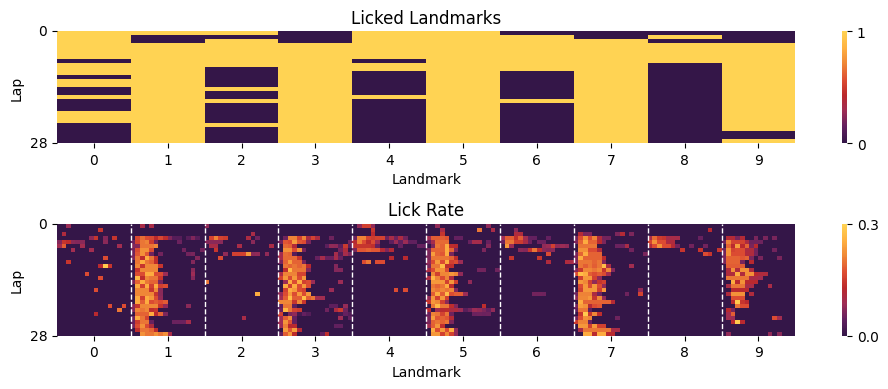

In [94]:
# Plot the binary and lick rate maps for each landmark 
fig, ax = plt.subplots(2, 1, figsize=(10,4), sharex=False, sharey=True)
ax = ax.ravel()

# Plot binary licks
sns.heatmap(binary_licked_lms, ax=ax[0], cmap=tm_palette, vmin=0, vmax=1, cbar_kws={"ticks": [0, 1]})

# Plot lick rate
max_lick_rate = np.round(np.nanmax(lm_lick_rate), 1)
sns.heatmap(lm_lick_rate, ax=ax[1], cmap=tm_palette, vmin=0, vmax=max_lick_rate, cbar_kws={"ticks": [0, max_lick_rate]})
for i in range(1, num_landmarks):
    ax[1].axvline(i * 16, color='white', linestyle='--', linewidth=1)

for axis in ax:
    axis.set_yticks([0,binary_licked_lms.shape[0]])
    axis.set_yticklabels([0,binary_licked_lms.shape[0]])
    axis.set_xlabel('Landmark')
    axis.set_ylabel('Lap')
    
ax[0].set_title('Licked Landmarks')
ax[1].set_title('Lick Rate')
tick_positions = [i * 16 + 16 // 2 for i in range(num_landmarks)]
tick_labels = list(range(num_landmarks))
ax[1].set_xticks(tick_positions)
ax[1].set_xticklabels(tick_labels, rotation=0)

plt.tight_layout()

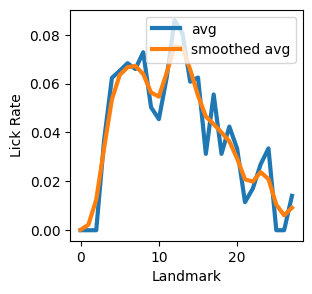

In [116]:
# Is there a threshold to define change in behaviour state? 
test_lm_lick_rate = np.mean(lm_lick_rate[:, -16:], axis=1)
filtered_test_lm_lick_rate = gaussian_filter1d(test_lm_lick_rate, sigma=1)

plt.figure(figsize=(3,3))
plt.plot(test_lm_lick_rate, linewidth=3, label='avg')
plt.plot(filtered_test_lm_lick_rate, linewidth=3, label='smoothed avg')
plt.xlabel('Landmark')
plt.ylabel('Lick Rate')
plt.legend(loc='upper right')


#### Get reward psth and lick rate

67 neurons are tuned to reward.


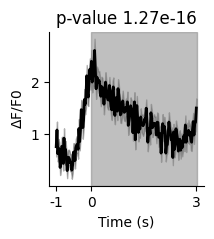

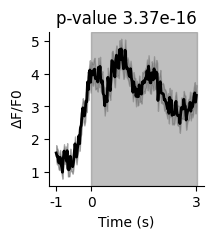

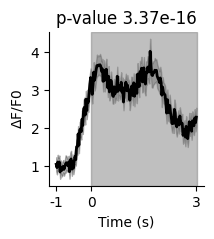

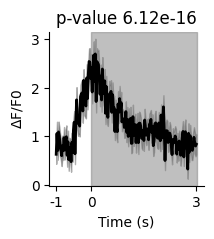

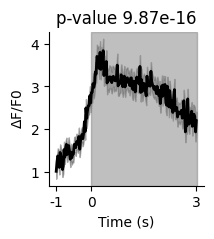

In [43]:
# Get reward PSTH
reward_psth, average_reward_psth = get_psth(data=DF_F, neurons=neurons_considered, event_idx=session['reward_idx'], \
                                                            time_around=1)

# plot_avg_psth(average_psth=average_reward_psth, event='Reward', zscoring=True, time_around=1)

# Get reward-tuned neurons
significant_neurons_reward, stat, pvalue = get_tuned_neurons(reward_psth, event='reward', time_around=1, plot_neurons=False)

# Plot the strongest responding cells 
pvalue = np.array(pvalue).flatten()
strongest_cell_idx = np.argsort(pvalue)
original_cell_idx = [cell for cell in strongest_cell_idx if cell in significant_neurons_reward]

# Plot reward PSTH for -1 to +3 s
long_reward_psth, long_average_reward_psth = get_psth(data=DF_F, neurons=neurons_considered, event_idx=session['reward_idx'], \
                                                            time_around=(-1,3))

plot_psth_single_neurons(long_reward_psth, long_average_reward_psth, neurons=original_cell_idx[0:5], time_around=(-1,3), num_neurons=5, pvalues=pvalue[strongest_cell_idx[0:5]], zscoring=False, avg_only=True)

Number of licks considered: 246


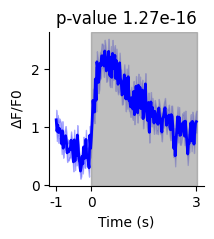

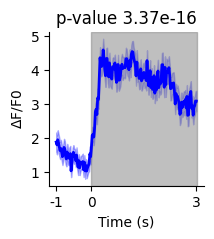

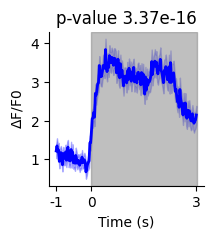

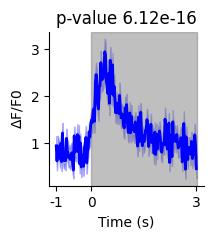

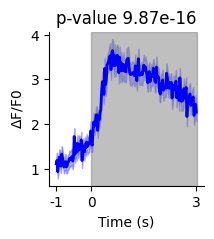

In [44]:
# Collect all licks 
licks = get_lick_types(session, VR_data, nidaq_data)

# Get first licks from each type
first_licks, all_first_licks = get_first_licks(session, VR_data, nidaq_data)

# Get lick PSTH for -1 to +3 s using only rewarded landmarks    
long_lick_psth, long_average_lick_psth = get_psth(data=DF_F, neurons=neurons_considered, event_idx=first_licks[1], \
                                                            time_around=(-1,3))

plot_psth_single_neurons(long_lick_psth, long_average_lick_psth, neurons=original_cell_idx[0:5], time_around=(-1,3), num_neurons=5, pvalues=pvalue[strongest_cell_idx[0:5]], zscoring=False, avg_only=True, color='blue')


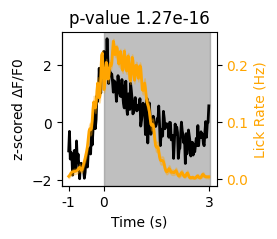

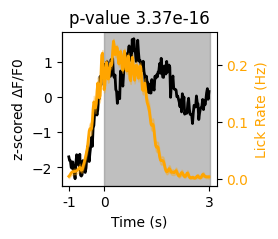

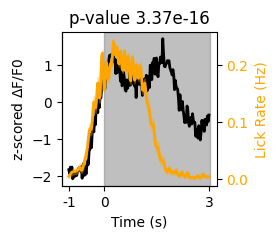

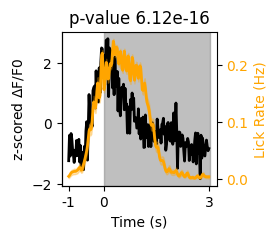

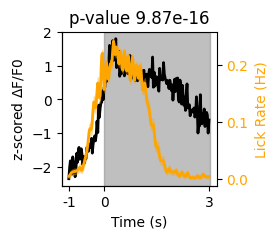

In [92]:
# Get lick rate for time window around rewards
event_lick_rate = get_event_lick_rate(session, event_idx=session['reward_idx'], time_around=(-1,3))

plot_psth_single_neurons(psth=long_reward_psth, average_psth=long_average_reward_psth, neurons=original_cell_idx[0:5], \
                         time_around=(-1, 3), num_neurons=5, avg_only=True, zscoring=True, \
                            event_lick_rate=event_lick_rate, pvalues=pvalue[strongest_cell_idx[0:5]], color=None)

#### Correlation sliding window with licks

In [ ]:
# Get relevant events 
num_lms_considered = np.round((num_lms // 10) * 10)
num_laps = int(num_lms_considered / 10)

first_licks, _ = get_first_licks(session, VR_data, nidaq_data)
first_licks = {id: np.array(lst) for id, lst in first_licks.items()}

# Landmark licks and non-licks
lick_ids = [1, 2, 3, 4, 8, 9, 10]
lick_events = np.sort(np.concatenate([first_licks[i] for i in lick_ids]))


Number of licks considered: 339


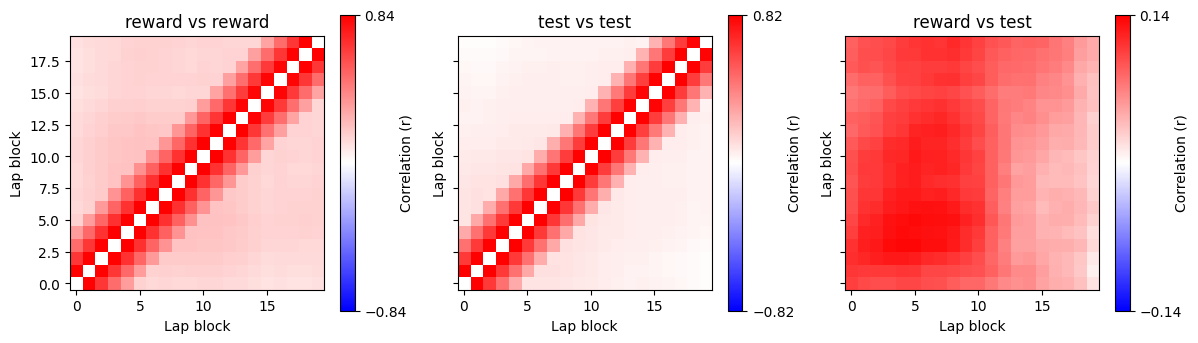

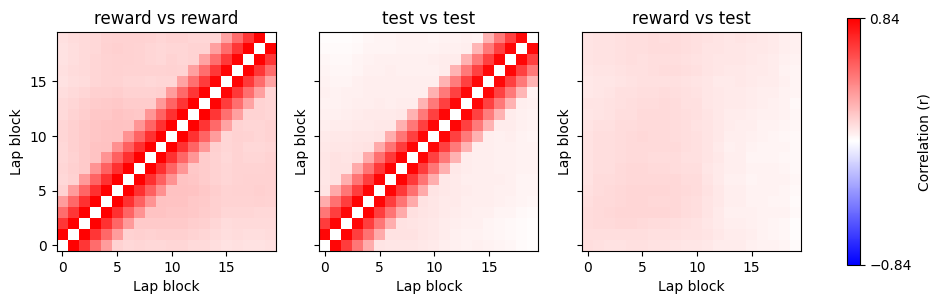

In [ ]:
# Sliding window across T5 reward-licks and test-licks correlations using licks
if protocol_num == 5 and animal == 'TAA0000066':
    
    # Get landmarks PSTH of fake neuron
    landmark_psth, average_landmark_psth = get_landmark_psth(data=DF_F, neurons=neurons_considered, event_idx=lick_events[:num_lms_considered], \
                                                                num_landmarks=num_landmarks, time_around=1)
         
    # Find rewarded landmarks
    rew_idx = {}    
    for g, goal in enumerate(ABCD_goals):
        rew_idx[goal] = np.array([idx for idx in session['rewarded_landmarks'] \
                                if session['all_lms'][idx] == session['goal_landmark_id'][goal-1]])

    # Get rolling reward avg
    window_size = 5     # laps 
    num_windows = len(rew_idx[ABCD_goals[0]]) 
    rolling_avg_reward_psth = np.zeros((landmark_psth.shape[0], num_windows-window_size, landmark_psth.shape[2])) 

    for i in range(num_windows-window_size):
        psths_considered = np.concatenate([landmark_psth[:, rew_idx[goal][i]:rew_idx[goal][i+window_size]:num_landmarks, :] for goal in ABCD_goals], axis=1)
        # shape: num_neurons x window_size * num_goals x num_timebins

        rolling_avg_reward_psth[:, i, :] = np.mean(psths_considered, axis=1) 
        # shape: num_neurons x num_windows x num_timebins

    # Get rolling test avg
    valid_test_indices = np.array([idx for idx in session['test_idx'] if (idx > session['rewarded_landmarks'][0] and idx < session['rewarded_landmarks'][-1]+3)])
    num_windows = int(len(valid_test_indices - window_size + 1))
    rolling_avg_test_psth = np.zeros((landmark_psth.shape[0], num_windows-window_size, landmark_psth.shape[2])) 
    
    for i in range(num_windows-window_size):
        rolling_avg_test_psth[:, i, :] = np.mean(landmark_psth[:, valid_test_indices[i]:valid_test_indices[i+window_size]:num_landmarks, :], axis=1)

    # Get correlation matrix of average psths in rolling lap blocks
    conditions = ['reward', 'test']
    average_psths = [rolling_avg_reward_psth, rolling_avg_test_psth]

    similarity_matrices = get_window_similarity_matrix(average_psths, conditions, population=False, zscoring=True, plot=True)

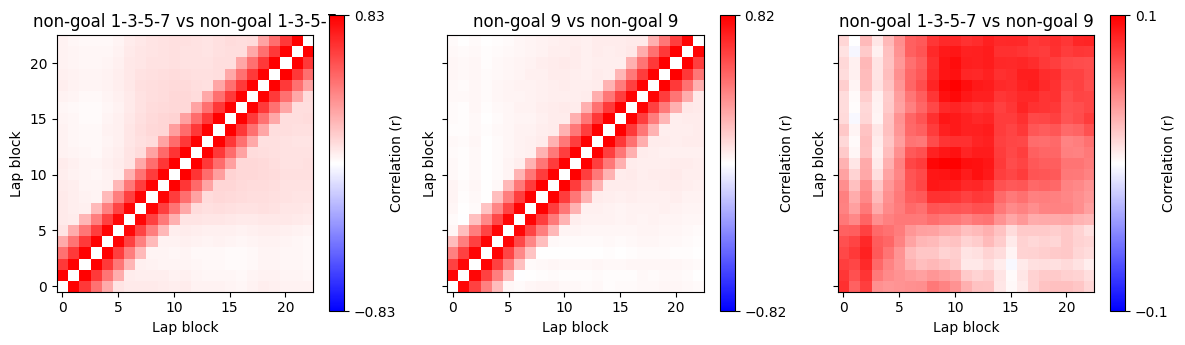

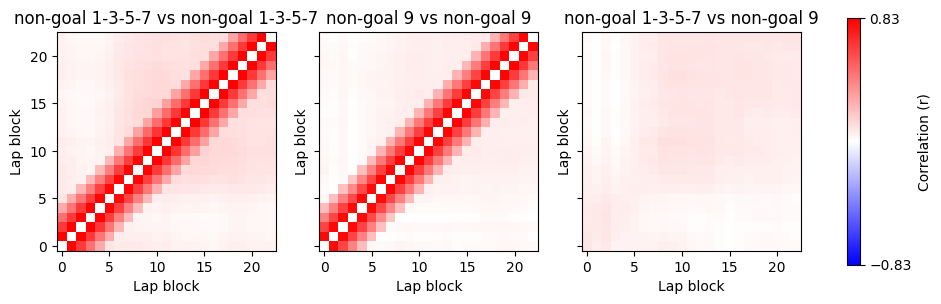

In [49]:
# Sliding window over laps of pairwise non-goal correlations 
if protocol_num == 5 and animal == 'TAA0000066':
    
    # Get landmarks PSTH of fake neuron
    landmark_psth, average_landmark_psth = get_landmark_psth(data=DF_F, neurons=neurons_considered, event_idx=lick_events[:num_lms_considered], \
                                                                num_landmarks=num_landmarks, time_around=1)
     
    # Find non-goal landmarks
    non_goal_idx = {}    
    for g, non_goal in enumerate([0,2,4,6,8]):
        non_goal_idx[non_goal] = np.array([idx for idx in session['non_goals_idx'] \
                                if session['all_lms'][idx] == session['non_goal_landmark_id'][g]
                                and (idx < num_lms_considered)])
    num_windows = len(non_goal_idx[0])

    # Get rolling non-goal avg
    window_size = 5     # laps 
    rolling_avg_0246_psth = np.zeros((landmark_psth.shape[0], num_windows-window_size, landmark_psth.shape[2])) 
    rolling_avg_8_psth = np.zeros((landmark_psth.shape[0], num_windows-window_size, landmark_psth.shape[2])) 

    for i in range(num_windows-window_size):
        psths_considered = np.concatenate([landmark_psth[:, non_goal_idx[non_goal][i]:non_goal_idx[non_goal][i+window_size]:num_landmarks, :] for non_goal in [0,2,4,6]], axis=1)
        # shape: num_neurons x window_size * num_goals x num_timebins

        rolling_avg_0246_psth[:, i, :] = np.mean(psths_considered, axis=1) 
        rolling_avg_8_psth[:, i, :] = np.nanmean(landmark_psth[:, non_goal_idx[8][i]:non_goal_idx[8][i+window_size]:num_landmarks, :], axis=1)
        # shape: num_neurons x num_windows x num_timebins

    # Get the pairwise correlations of rolling lap blocks
    conditions = ['non-goal 1-3-5-7', 'non-goal 9']
    average_psths = [rolling_avg_0246_psth, rolling_avg_8_psth]

    # Get correlation matrix of average psths in rolling lap blocks
    similarity_matrices = get_window_similarity_matrix(average_psths, conditions, population=False, zscoring=True, plot=True)

In [ ]:
# TODO: Sliding window over laps of pairwise between landmark correlations 
if protocol_num == 5 and animal == 'TAA0000066':

    # Define 'events' between landmarks 
    num_lms_considered = int(np.round((num_lms // 10) * 10))
    num_laps = int(num_lms_considered / num_landmarks)

    before_lm = []
    after_lm = []
    for i in np.arange(num_landmarks, num_lms_considered):  # skipping first lap 
        before_lm.append(len(np.arange(lm_exit_idx[i-1], lm_entry_idx[i])))
        after_lm.append(len(np.arange(lm_exit_idx[i], lm_entry_idx[i+1])))

    midpoints_before = np.rint(np.array(before_lm) / 2).astype(int)
    midpoints_after = np.rint(np.array(after_lm) / 2).astype(int)
    min_frames_around = np.min([midpoints_before, midpoints_after])
    # print(min_frames_around)

    new_time_around = min_frames_around / funcimg_frame_rate  # new time around to avoid overlaps with landmark 

    event_indices = []
    for i, idx in enumerate(np.arange(num_landmarks, num_lms_considered)):
        event_indices.append(lm_entry_idx[idx] - midpoints_before[i])

    # Get smoothed lick rate 
    session = get_smoothed_lick_rate(nidaq_data, session)
    
    # Get between-landmark PSTH  
    between_landmark_psth, average_between_landmark_psth = get_landmark_psth(data=session['smooth_lick_rate'], neurons=0, event_idx=event_indices, \
                                                                num_landmarks=num_landmarks, time_around=new_time_around)
    
    # Find number of 'gray' zones before rewards
    window_size = 5     # laps 
    before_rew_idx = {}    
    for g, goal in enumerate(ABCD_goals):
        before_rew_idx[goal] = np.array([idx for idx in session['rewarded_landmarks'] \
                                if session['all_lms'][idx] == session['goal_landmark_id'][goal-1]]) - num_landmarks  # shift indices back - first lap is not considered
        
        num_windows = len(before_rew_idx[goal]) 

    # Get rolling before-reward avg
    rolling_avg_before_reward_psth = np.zeros((between_landmark_psth.shape[0], num_windows-window_size, between_landmark_psth.shape[2])) 
    for i in range(num_windows-window_size):
        psths_considered = np.concatenate([between_landmark_psth[:, before_rew_idx[goal][i]:before_rew_idx[goal][i+window_size]:num_landmarks, :] for goal in ABCD_goals], axis=1)
        # shape: num_neurons x window_size * num_goals x num_timebins

        rolling_avg_before_reward_psth[:, i, :] = np.mean(psths_considered, axis=1) 
        # shape: num_neurons x num_windows x num_timebins

    # Get rolling before-test avg
    valid_before_test_idx = np.array([idx for idx in session['test_idx'] if (idx > session['rewarded_landmarks'][0] and idx < session['rewarded_landmarks'][-1]+3)]) - num_landmarks  # shift indices back - first lap is not considered
    num_windows = int(len(valid_before_test_idx - window_size + 1))
    rolling_avg_before_test_psth = np.zeros((between_landmark_psth.shape[0], num_windows-window_size, between_landmark_psth.shape[2])) 
    
    for i in range(num_windows-window_size):
        rolling_avg_before_test_psth[:, i, :] = np.mean(between_landmark_psth[:, valid_before_test_idx[i]:valid_before_test_idx[i+window_size]:num_landmarks, :], axis=1)

    # Get the pairwise correlations of rolling lap blocks
    conditions = ['before-reward', 'before-test']
    average_psths = [rolling_avg_before_reward_psth, rolling_avg_before_test_psth]

    # Get correlation matrix of average psths in rolling lap blocks
    similarity_matrices = get_window_similarity_matrix(average_psths, conditions, population=False, zscoring=True, plot=True)

#### Correlation sliding window with lick rate

In [50]:
# Get relevant events and data 
num_lms_considered = np.round((num_lms // 10) * 10)
num_laps = int(num_lms_considered / 10)
    
all_reward_idx = np.sort(np.concatenate([session['reward_idx'], session['miss_rew_idx'], session['nongoal_rew_idx'], session['test_rew_idx']]))

# Get smoothed lick rate 
session = get_smoothed_lick_rate(nidaq_data, session)


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/athinaapostolelli/miniforge3/envs/suite2p/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/hb/19x78jb503d4_x8gkyw7xdz00000gn/T/ipykernel_4264/358019079.py", line 8, in <module>
    session = get_smoothed_lick_rate(nidaq_data, session)
  File "/Users/athinaapostolelli/Documents/SWC/VR_ABCD_project/VR_ABCD/neural_analysis_helpers.py", line 1988, in get_smoothed_lick_rate
  File "/Users/athinaapostolelli/Documents/SWC/VR_ABCD_project/VR_ABCD/neural_analysis_helpers.py", line 1956, in threshold_nidaq_licks
  File "/Users/athinaapostolelli/.local/lib/python3.9/site-packages/numpy/lib/npyio.py", line 251, in __getitem__
    bytes = self.zip.open(key)
  File "/Users/athinaapostolelli/miniforge3/envs/suite2p/lib/python3.9/zipfile.py", line 1535, in open
    fheader = zef_file.read(sizeFileHeader)
  File "/Users/athinaapostolelli/minif

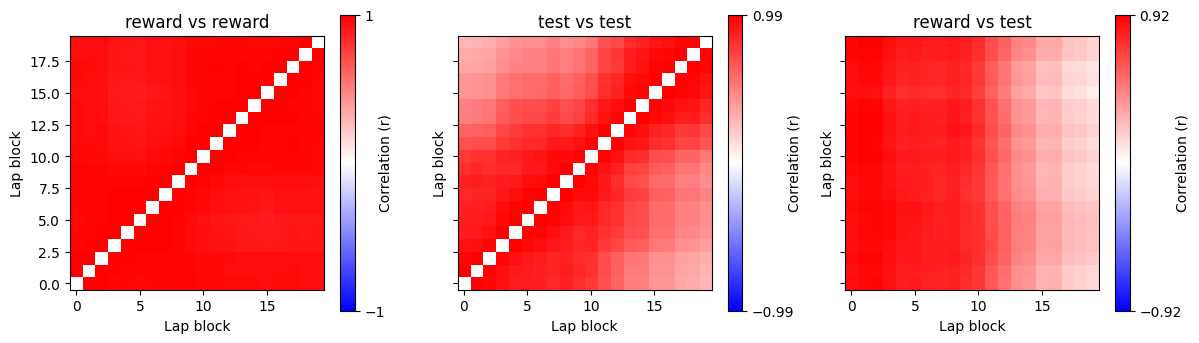

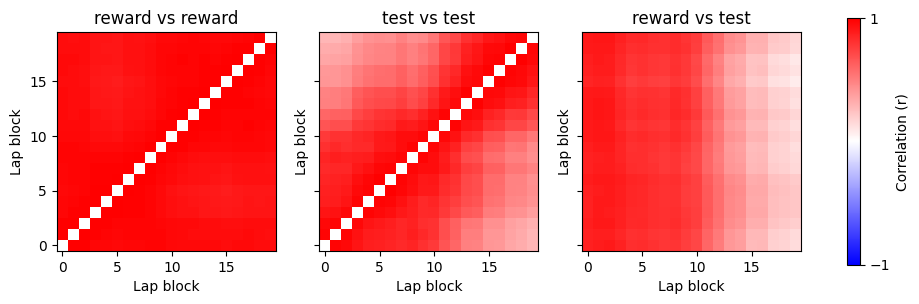

In [ ]:
# Sliding window across T5 reward-licks and test-licks correlations using lick rate as a fake neuron
if protocol_num == 5 and animal == 'TAA0000066':
    
    # Get landmarks PSTH of fake neuron
    landmark_psth, average_landmark_psth = get_landmark_psth(data=session['smooth_lick_rate'], neurons=0, event_idx=all_reward_idx[:num_lms_considered], \
                                                                num_landmarks=num_landmarks, time_around=1)
         
    # Find rewarded landmarks
    rew_idx = {}    
    for g, goal in enumerate(ABCD_goals):
        rew_idx[goal] = np.array([idx for idx in session['rewarded_landmarks'] \
                                if session['all_lms'][idx] == session['goal_landmark_id'][goal-1]])

    # Get rolling reward avg
    window_size = 5     # laps 
    num_windows = len(rew_idx[ABCD_goals[0]]) 
    rolling_avg_reward_psth = np.zeros((landmark_psth.shape[0], num_windows-window_size, landmark_psth.shape[2])) 

    for i in range(num_windows-window_size):
        psths_considered = np.concatenate([landmark_psth[:, rew_idx[goal][i]:rew_idx[goal][i+window_size]:num_landmarks, :] for goal in ABCD_goals], axis=1)
        # shape: num_neurons x window_size * num_goals x num_timebins

        rolling_avg_reward_psth[:, i, :] = np.mean(psths_considered, axis=1) 
        # shape: num_neurons x num_windows x num_timebins

    # Get rolling test avg
    valid_test_indices = np.array([idx for idx in session['test_idx'] if (idx > session['rewarded_landmarks'][0] and idx < session['rewarded_landmarks'][-1]+3)])
    num_windows = int(len(valid_test_indices - window_size + 1))
    rolling_avg_test_psth = np.zeros((landmark_psth.shape[0], num_windows-window_size, landmark_psth.shape[2])) 
    
    for i in range(num_windows-window_size):
        rolling_avg_test_psth[:, i, :] = np.mean(landmark_psth[:, valid_test_indices[i]:valid_test_indices[i+window_size]:num_landmarks, :], axis=1)

    # Get correlation matrix of average psths in rolling lap blocks
    conditions = ['reward', 'test']
    average_psths = [rolling_avg_reward_psth, rolling_avg_test_psth]

    similarity_matrices = get_window_similarity_matrix(average_psths, conditions, population=False, zscoring=True, plot=True)

/Users/athinaapostolelli/Documents/SWC/VR_ABCD_project/VR_ABCD/neural_analysis_helpers.py:1054: RuntimeWarning:

Mean of empty slice

/Users/athinaapostolelli/Documents/SWC/VR_ABCD_project/VR_ABCD/neural_analysis_helpers.py:1100: RuntimeWarning:

Mean of empty slice



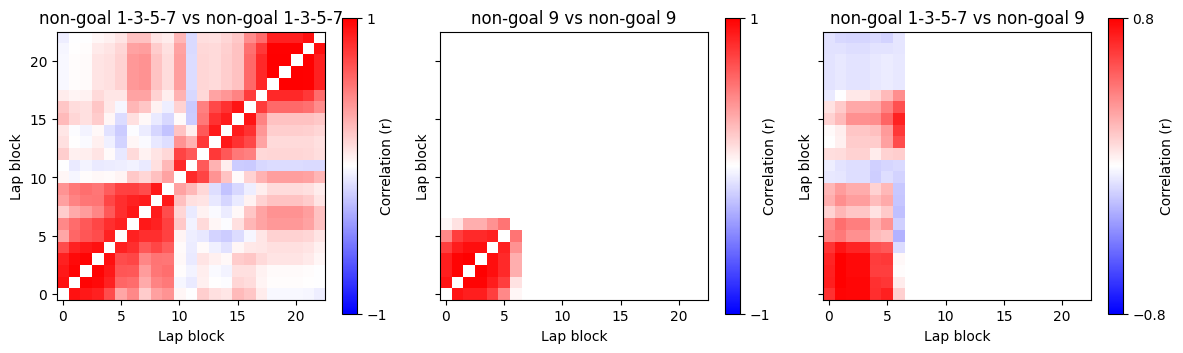

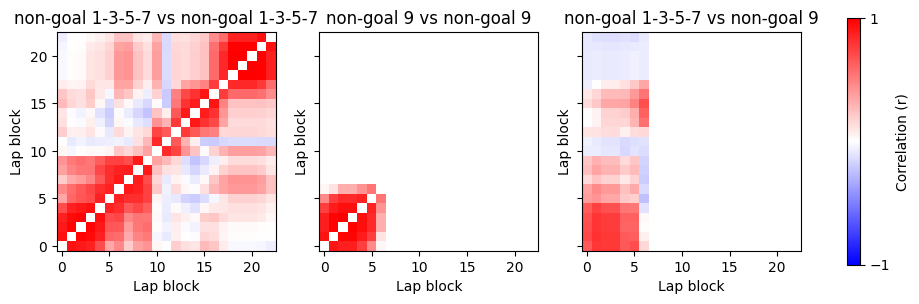

In [ ]:
# Sliding window over laps of pairwise non-goal correlations 
if protocol_num == 5 and animal == 'TAA0000066':
    
    # Get landmarks PSTH of fake neuron
    landmark_psth, average_landmark_psth = get_landmark_psth(data=session['smooth_lick_rate'], neurons=0, event_idx=all_reward_idx[:num_lms_considered], \
                                                                num_landmarks=num_landmarks, time_around=1)
     
    # Find non-goal landmarks
    non_goal_idx = {}    
    for g, non_goal in enumerate([0,2,4,6,8]):
        non_goal_idx[non_goal] = np.array([idx for idx in session['non_goals_idx'] \
                                if session['all_lms'][idx] == session['non_goal_landmark_id'][g]
                                and (idx < num_lms_considered)])
    num_windows = len(non_goal_idx[0])

    # Get rolling non-goal avg
    window_size = 5     # laps 
    rolling_avg_0246_psth = np.zeros((landmark_psth.shape[0], num_windows-window_size, landmark_psth.shape[2])) 
    rolling_avg_8_psth = np.zeros((landmark_psth.shape[0], num_windows-window_size, landmark_psth.shape[2])) 

    for i in range(num_windows-window_size):
        psths_considered = np.concatenate([landmark_psth[:, non_goal_idx[non_goal][i]:non_goal_idx[non_goal][i+window_size]:num_landmarks, :] for non_goal in [0,2,4,6]], axis=1)
        # shape: num_neurons x window_size * num_goals x num_timebins

        rolling_avg_0246_psth[:, i, :] = np.mean(psths_considered, axis=1) 
        rolling_avg_8_psth[:, i, :] = np.nanmean(landmark_psth[:, non_goal_idx[8][i]:non_goal_idx[8][i+window_size]:num_landmarks, :], axis=1)
        # shape: num_neurons x num_windows x num_timebins

    # Get the pairwise correlations of rolling lap blocks
    conditions = ['non-goal 1-3-5-7', 'non-goal 9']
    average_psths = [rolling_avg_0246_psth, rolling_avg_8_psth]

    # Get correlation matrix of average psths in rolling lap blocks
    similarity_matrices = get_window_similarity_matrix(average_psths, conditions, population=False, zscoring=True, plot=True)

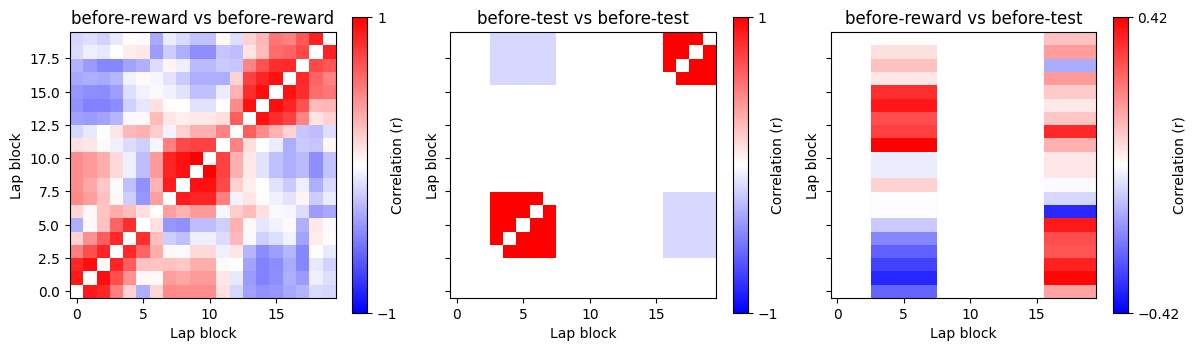

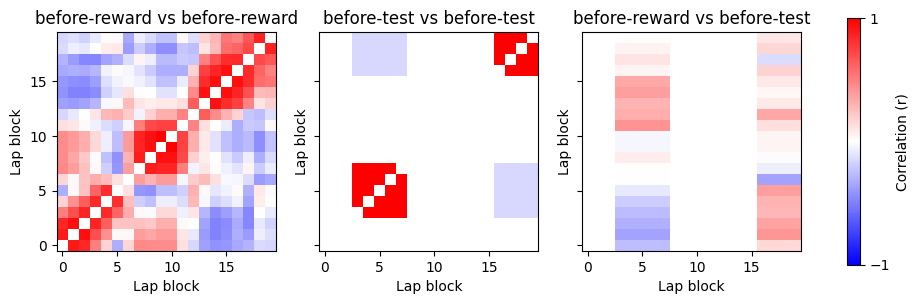

In [ ]:
# Sliding window over laps of pairwise between landmark correlations 
if protocol_num == 5 and animal == 'TAA0000066':

    # Define 'events' between landmarks 
    before_lm = []
    after_lm = []
    for i in np.arange(num_landmarks, num_lms_considered):  # skipping first lap 
        before_lm.append(len(np.arange(lm_exit_idx[i-1], lm_entry_idx[i])))
        after_lm.append(len(np.arange(lm_exit_idx[i], lm_entry_idx[i+1])))

    midpoints_before = np.rint(np.array(before_lm) / 2).astype(int)
    midpoints_after = np.rint(np.array(after_lm) / 2).astype(int)
    min_frames_around = np.min([midpoints_before, midpoints_after])
    # print(min_frames_around)

    new_time_around = min_frames_around / funcimg_frame_rate  # new time around to avoid overlaps with landmark 

    event_indices = []
    for i, idx in enumerate(np.arange(num_landmarks, num_lms_considered)):
        event_indices.append(lm_entry_idx[idx] - midpoints_before[i])

    # Get smoothed lick rate 
    session = get_smoothed_lick_rate(nidaq_data, session)
    
    # Get between-landmark PSTH  
    between_landmark_psth, average_between_landmark_psth = get_landmark_psth(data=session['smooth_lick_rate'], neurons=0, event_idx=event_indices, \
                                                                num_landmarks=num_landmarks, time_around=new_time_around)
    
    # Find number of 'gray' zones before rewards
    window_size = 5     # laps 
    before_rew_idx = {}    
    for g, goal in enumerate(ABCD_goals):
        before_rew_idx[goal] = np.array([idx for idx in session['rewarded_landmarks'] \
                                if session['all_lms'][idx] == session['goal_landmark_id'][goal-1]]) - num_landmarks  # shift indices back - first lap is not considered
        
        num_windows = len(before_rew_idx[goal]) 

    # Get rolling before-reward avg
    rolling_avg_before_reward_psth = np.zeros((between_landmark_psth.shape[0], num_windows-window_size, between_landmark_psth.shape[2])) 
    for i in range(num_windows-window_size):
        psths_considered = np.concatenate([between_landmark_psth[:, before_rew_idx[goal][i]:before_rew_idx[goal][i+window_size]:num_landmarks, :] for goal in ABCD_goals], axis=1)
        # shape: num_neurons x window_size * num_goals x num_timebins

        rolling_avg_before_reward_psth[:, i, :] = np.mean(psths_considered, axis=1) 
        # shape: num_neurons x num_windows x num_timebins

    # Get rolling before-test avg
    valid_before_test_idx = np.array([idx for idx in session['test_idx'] if (idx > session['rewarded_landmarks'][0] and idx < session['rewarded_landmarks'][-1]+3)]) - num_landmarks  # shift indices back - first lap is not considered
    num_windows = int(len(valid_before_test_idx - window_size + 1))
    rolling_avg_before_test_psth = np.zeros((between_landmark_psth.shape[0], num_windows-window_size, between_landmark_psth.shape[2])) 
    
    for i in range(num_windows-window_size):
        rolling_avg_before_test_psth[:, i, :] = np.mean(between_landmark_psth[:, valid_before_test_idx[i]:valid_before_test_idx[i+window_size]:num_landmarks, :], axis=1)

    # Get the pairwise correlations of rolling lap blocks
    conditions = ['before-reward', 'before-test']
    average_psths = [rolling_avg_before_reward_psth, rolling_avg_before_test_psth]

    # Get correlation matrix of average psths in rolling lap blocks
    similarity_matrices = get_window_similarity_matrix(average_psths, conditions, population=False, zscoring=True, plot=True)

#### Lick rate map in split behaviour phases 

#### t-test around behaviour boundaries 

In [ ]:
# Perform a t-test around the behaviour boundaries 

# Collect the relevant data
all_reward_idx = np.sort(np.concatenate([session['reward_idx'], session['miss_rew_idx'], session['nongoal_rew_idx'], session['test_rew_idx']]))

landmark_psth, average_landmark_psth = get_landmark_psth(data=DF_F, neurons=neurons_considered, event_idx=all_reward_idx[:num_lms_considered], \
                                                            num_landmarks=num_landmarks, time_around=1)

# Split trials into behaviour segments
split_indices = {}
for i in range(3):
    if i == 0:
        trials = np.arange(0, 70)   # laps 0-7
    elif i == 1:
        trials = np.arange(70, 200)     # laps 7-20
    elif i == 2:
        trials = np.arange(200, num_lms)   # laps 20-end

    split_indices[i] = valid_test_indices[np.isin(valid_test_indices, trials)]

# Split psths into behaviour segments
split_test_psths = [landmark_psth[:, split_idx, :] for id, split_idx in split_indices.items()]

# Take average across timebins for each neuron and each trial 
split_average_test_psths = [np.mean(psth, axis=2) for psth in split_test_psths]
# for split in split_average_test_psths:
#     print(split.shape)


{0: array([39, 49, 59, 69])}
{0: array([39, 49, 59, 69]), 1: array([ 79,  89,  99, 109, 119, 129, 139, 149, 159, 169, 179, 189, 199])}
{0: array([39, 49, 59, 69]), 1: array([ 79,  89,  99, 109, 119, 129, 139, 149, 159, 169, 179, 189, 199]), 2: array([209, 219, 229, 239, 249, 259, 269, 279])}


In [101]:
print(split_average_test_psths[1].shape)
print(split_average_test_psths[2].shape)


(319, 13)
(319, 8)


110
[  0   1   2   3   6   8   9  12  13  14  16  21  23  25  27  29  30  33
  34  41  44  47  48  50  51  52  53  54  56  59  63  64  66  72  73  75
  76  80  81  85  86  92  93  96 101 104 106 110 112 114 115 122 123 124
 125 127 129 130 131 134 137 138 141 143 146 147 153 154 158 163 166 167
 170 171 172 173 180 185 186 192 193 198 200 206 209 210 211 217 218 220
 221 222 224 225 226 227 228 231 233 234 235 236 240 242 246 248 249 251
 254 255 259 262 266 268 271 276 278 279 281 282 285 287 288 289 293 294
 296 297 298 301 306 307 308 309 311 312 313 314 316 317 318 323 325 328
 331 333 334 335 336 337 338 339 343 344 345 346 347 348 353 356 359 361
 362 365 366 367 368 369 370 371 373 374 375 376 377 378 380 381 382 384
 385 387 390 392 393 394 395 396 398 400 402 405 406 409 410 412 413 414
 417 424 426 427 431 432 433 435 437 438 441 442 443 444 446 447 448 452
 453 454 455 459 461 462 463 464 465 467 470 473 475 476 477 479 483 484
 485 487 489 493 494 495 496 498 499 503 504 50

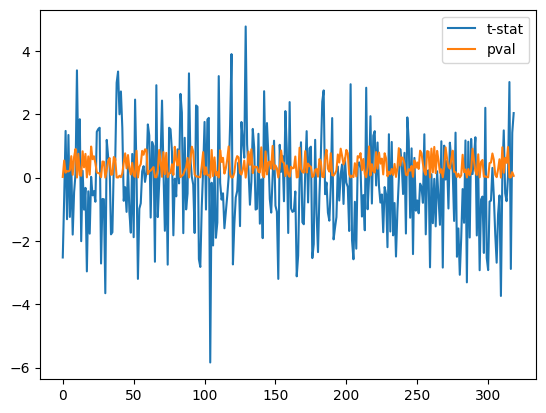

In [103]:
# two-sided t-test for each neuron in alternation vs discrimination (assume equal population variances)
t_stat, t_pval = stats.ttest_ind(split_average_test_psths[1], split_average_test_psths[2], axis=1, \
                                        equal_var=True, nan_policy='raise') 

plt.plot(t_stat, label='t-stat')
plt.plot(t_pval, label='pval')
plt.legend()
# Set arbitrary t-value threshold to 2 
test_neurons = neurons_considered[np.where(np.abs(t_stat) > 1.5)[0]]
print(len(test_neurons))

print(neurons_considered)

remaining_neurons = np.setdiff1d(neurons_considered, test_neurons)
print(remaining_neurons)

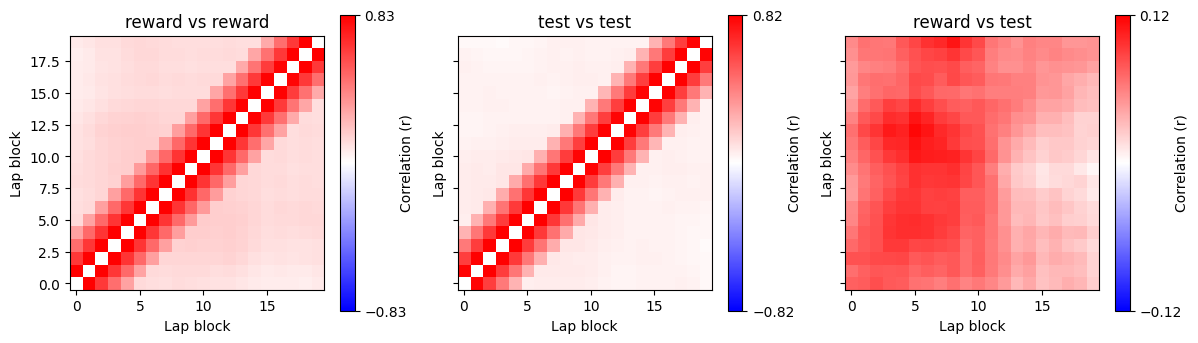

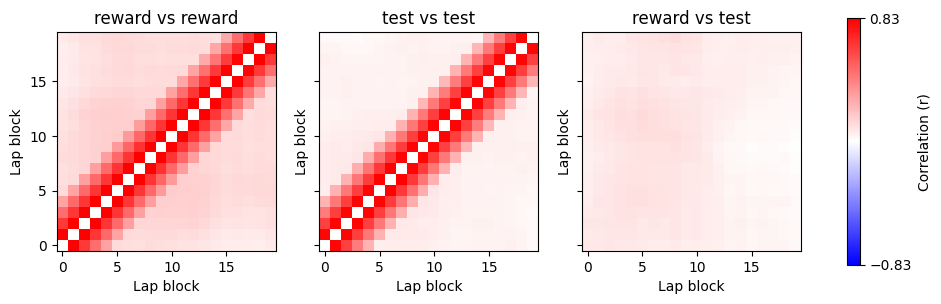

In [100]:
# Remove these neurons are repeat correlations (reward-locked activity)
# Sliding window across T5 reward and test correlations
if protocol_num == 5 and animal == 'TAA0000066':
    num_lms_considered = np.round((num_lms // 10) * 10)
    ABCD_goals = [1,2,3,4]
    all_reward_idx = np.sort(np.concatenate([session['reward_idx'], session['miss_rew_idx'], session['nongoal_rew_idx'], session['test_rew_idx']]))

    landmark_psth, average_landmark_psth = get_landmark_psth(data=DF_F, neurons=remaining_neurons, event_idx=all_reward_idx[:num_lms_considered], \
                                                                num_landmarks=num_landmarks, time_around=1)
         
    window_size = 5     # laps 
    
    # Get rolling reward avg
    rew_idx = {}    
    for g, goal in enumerate(ABCD_goals):
        rew_idx[goal] = np.array([idx for idx in session['rewarded_landmarks'] \
                                if session['all_lms'][idx] == session['goal_landmark_id'][goal-1]])
        
        num_windows = len(rew_idx[goal]) 

    rolling_avg_reward_psth = np.zeros((landmark_psth.shape[0], num_windows-window_size, landmark_psth.shape[2])) 

    for i in range(num_windows-window_size):
        psths_considered = np.concatenate([landmark_psth[:, rew_idx[goal][i]:rew_idx[goal][i+window_size]:num_landmarks, :] for goal in ABCD_goals], axis=1)
        # shape: num_neurons x window_size * num_goals x num_timebins

        rolling_avg_reward_psth[:, i, :] = np.mean(psths_considered, axis=1) 
        # shape: num_neurons x num_windows x num_timebins

    # Get rolling test avg
    valid_test_indices = np.array([idx for idx in session['test_idx'] if (idx > session['rewarded_landmarks'][0] and idx < session['rewarded_landmarks'][-1]+3)])
    num_windows = int(len(valid_test_indices - window_size + 1))
    rolling_avg_test_psth = np.zeros((landmark_psth.shape[0], num_windows-window_size, landmark_psth.shape[2])) 
    
    for i in range(num_windows-window_size):
        rolling_avg_test_psth[:, i, :] = np.mean(landmark_psth[:, valid_test_indices[i]:valid_test_indices[i+window_size]:num_landmarks, :], axis=1)

    # Get the pairwise correlations of rolling lap blocks
    conditions = ['reward', 'test']
    average_psths = [rolling_avg_reward_psth, rolling_avg_test_psth]

    # Get correlation matrix of average psths in rolling lap blocks
    similarity_matrices = get_window_similarity_matrix(average_psths, conditions, population=False, zscoring=True, plot=True)